# Рубежный контроль №1

## Технологии разведочного анализа и обработки данных

Ф.И.О.: Волощук А.Д.

Группа: ИУ5-62Б

Вариант: 6

Задача: №1 — корреляционный анализ

Набор данных: graduate-admissions из Kaggle

## 1. Импорт библиотек

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

## 2. Загрузка данных

In [3]:
df = pd.read_csv('Admission_Predict_Ver1.1.csv')

## 3. Проверка пропусков, удаление Serial No.

In [4]:
print(df.isnull().sum())
df = df.drop(columns=['Serial No.'])

Serial No.           0
GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
dtype: int64


## 4. Матрица корреляций

In [5]:
corr_matrix = df.corr()
corr_with_target = corr_matrix['Chance of Admit '].sort_values(ascending=False)
print(corr_with_target)

Chance of Admit      1.000000
CGPA                 0.882413
GRE Score            0.810351
TOEFL Score          0.792228
University Rating    0.690132
SOP                  0.684137
LOR                  0.645365
Research             0.545871
Name: Chance of Admit , dtype: float64


## 5. Тепловая карта

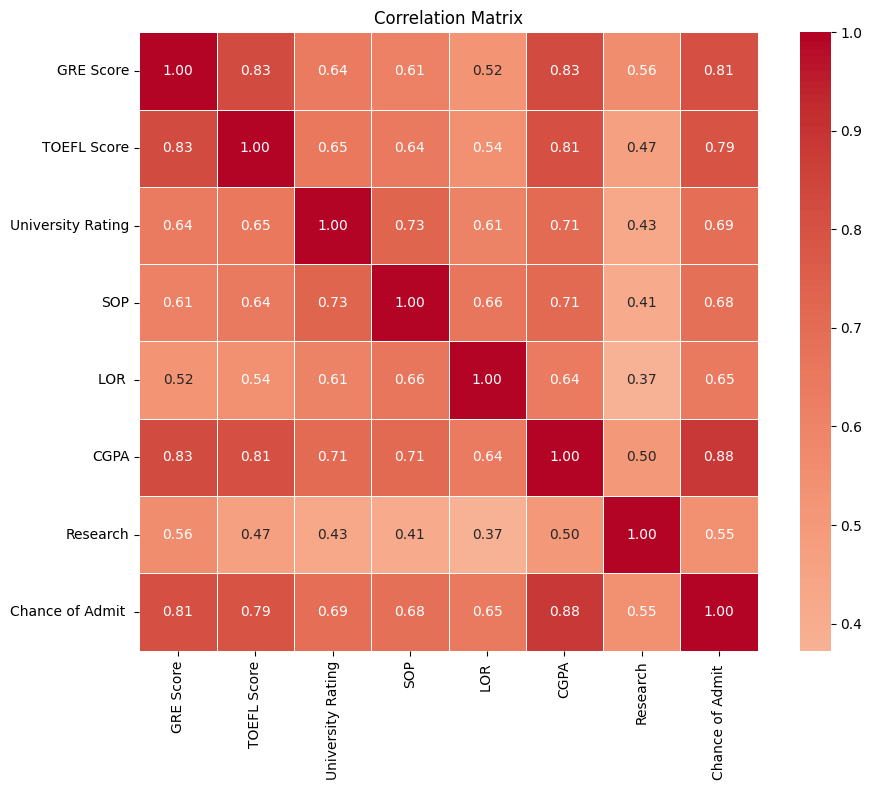

In [6]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True, linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

## 6. Гистограмма для CGPA

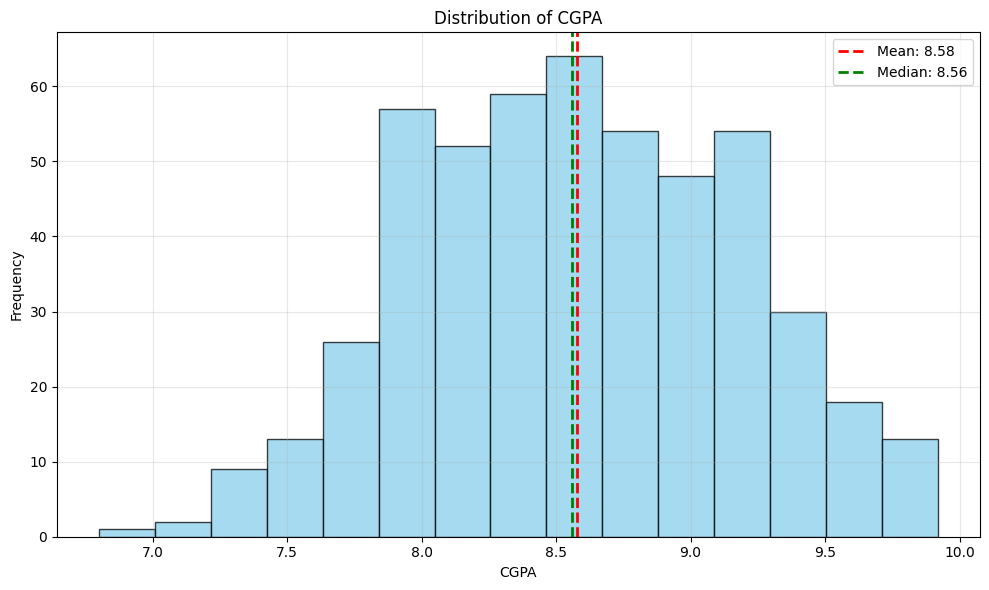

count    500.000000
mean       8.576440
std        0.604813
min        6.800000
25%        8.127500
50%        8.560000
75%        9.040000
max        9.920000
Name: CGPA, dtype: float64


In [7]:
chosen_column = 'CGPA'
plt.figure(figsize=(10, 6))
plt.hist(df[chosen_column], bins=15, alpha=0.75, color='skyblue', edgecolor='black')
plt.axvline(df[chosen_column].mean(), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {df[chosen_column].mean():.2f}')
plt.axvline(df[chosen_column].median(), color='green', linestyle='dashed', linewidth=2, label=f'Median: {df[chosen_column].median():.2f}')
plt.title(f'Distribution of {chosen_column}')
plt.xlabel(chosen_column)
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(df[chosen_column].describe())

## 7. Выводы

* Пропуски отсутствуют — данные готовы для моделирования.
* Сильнее всего с шансом поступления коррелируют: CGPA (0.88), GRE (0.81), TOEFL (0.79). Остальные признаки слабее.
* Модели: подходят линейная регрессия, случайный лес, бустинг. Выборки (500 строк) достаточно.
* Вклад признаков: главные — CGPA, GRE, TOEFL; University Rating, SOP, LOR, Research — вспомогательные.
* CGPA распределён почти нормально (среднее 8.58, медиана 8.56), что удобно для анализа.

Датасет пригоден для построения качественных регрессионных моделей с высокой предсказательной способностью. Наибольший вклад ожидается от CGPA, GRE и TOEFL; остальные признаки могут использоваться для тонкой настройки или быть исключены при необходимости сокращения числа параметров.